In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import fsps
from jax import jit
from tqdm import tqdm
from astropy import constants as const
tiny_number = 1e-70

from ceridwen.ssps.ssp_data import SSPData
from ceridwen.csp.csp import CSPBasis, fnu2flam

T_UNIV = 13.8  # Gyr, age of the universe
N_T = 100     # number of time steps for SFH

def gaussian_burst(tau, center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)

t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

sfr_bimodal = (gaussian_burst(tau, 0.05, 0.03, 1.0) +
               gaussian_burst(tau, 11.0, 0.8, 0.7))
zh = jnp.full_like(t, 10**-4.3477116)  # constant metallicity (Z=0.02)

ssp_data = SSPData.load('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')



In [ ]:

def fnu2flam(lam, fnu):
    """Convert f_nu [erg/s/cm^2/Hz] to f_lambda [erg/s/cm^2/Å]."""
    c = 2.998e18  # Å/s
    return c * (fnu / (lam**2))

def add_zh(zh, lookback_time=None, forward_time=None, tuniv=13.8):
    """
    Add a star formation history (SFH) for a CSP.
    Parameters:
        zh (array-like): The metallicity at the given ages.
            Example: [0.1, 0.2, 0.3, 0.4]
        
        lookback_time (array-like, optional): Lookback times for the SFH in Gyr.
            Example: [1.0, 2.0, 3.0, 4.0]
        
        forward_time (array-like, optional): Forward times (age of the universe) for the SFH in Gyr.
            Example: [9.8, 10.8, 11.8, 12.8]
        
        tuniv (float, default 13.8): The age of the stellar population (in Gyr) for which to obtain a spectrum.
            Default: 13.8 Gyr

    Returns:
        tuple: A tuple containing:
            - sfh (jnp.ndarray): The star formation history array.
            Example output: jnp.array([0.1, 0.2, 0.3, 0.4])
            
            - sfh_times (jnp.ndarray): The corresponding times (lookback or forward) for the SFH.
            Example output with lookback_time: jnp.array([1.0, 2.0, 3.0, 4.0])
            Example output with forward_time: jnp.array([1.0, 2.0, 3.0, 4.0]) (computed as tuniv - forward_time)

    Usage:
        >>> add_sfh(sfh=[0.1, 0.2, 0.3, 0.4], lookback_time=[1.0, 2.0, 3.0, 4.0])
        >>> add_sfh(sfh=[0.1, 0.2, 0.3, 0.4], forward_time= [9.8, 10.8, 11.8, 12.8])
    """
    # Convert metallicity history to JAX array for efficient computation
    zh = jnp.array(zh)  # Ensure zh is a JAX array

    # Process time input - either lookback time (time before present) or forward time (age of universe)
    if lookback_time is not None:
        print('lookback time')  # Debug output for time mode
        lookback_time = jnp.array(lookback_time)
        # Convert from Gyr to years for internal calculations
        zh_times = lookback_time*1e9  
    elif forward_time is not None:
        print('forward time')  # Debug output for time mode  
        forward_time = jnp.array(forward_time)
        # Convert forward time to lookback time: lookback = tuniv - forward_time
        zh_times = tuniv*1e9 - forward_time*1e9  # Compute lookback time from forward time  
        print(zh_times)  # Debug output for computed times
    else:
        # Neither time specification provided - this is an error condition
        raise ValueError("Either 'lookback_time' or 'forward_time' must be provided.")
    
    # Note: This condition seems incorrect - zh_times should never be None at this point
    if zh_times != None:
        print('No times added for metallicity history, use lookback_time or forward_time of SFH')
    
    # Validate that metallicity and time arrays have consistent dimensions
    if zh.shape != zh_times.shape:
        raise ValueError(
            f"Shape mismatch: zh has shape {zh.shape}, but zh_times has shape {zh_times.shape}."
        )
    
    return zh, zh_times

def add_sfh(sfh, lookback_time=None, forward_time=None, tuniv=13.8):
    """
    Add a star formation history (SFH) for a CSP.
    Parameters:
        sfh (array-like): The star formation rate in solar masses per year at the given ages.
            Example: [0.1, 0.2, 0.3, 0.4]
        
        lookback_time (array-like, optional): Lookback times for the SFH in Gyr.
            Example: [1.0, 2.0, 3.0, 4.0]
        
        forward_time (array-like, optional): Forward times (age of the universe) for the SFH in Gyr.
            Example: [9.8, 10.8, 11.8, 12.8]
        
        tuniv (float, default 13.8): The age of the stellar population (in Gyr) for which to obtain a spectrum.
            Default: 13.8 Gyr

    Returns:
        tuple: A tuple containing:
            - sfh (jnp.ndarray): The star formation history array.
            Example output: jnp.array([0.1, 0.2, 0.3, 0.4])
            
            - sfh_times (jnp.ndarray): The corresponding times (lookback or forward) for the SFH.
            Example output with lookback_time: jnp.array([1.0, 2.0, 3.0, 4.0])
            Example output with forward_time: jnp.array([1.0, 2.0, 3.0, 4.0]) (computed as tuniv - forward_time)

    Usage:
        >>> add_sfh(sfh=[0.1, 0.2, 0.3, 0.4], lookback_time=[1.0, 2.0, 3.0, 4.0])
        >>> add_sfh(sfh=[0.1, 0.2, 0.3, 0.4], forward_time= [9.8, 10.8, 11.8, 12.8])
    """
    # Convert star formation history to JAX array for efficient computation
    sfh = jnp.array(sfh)  # Ensure sfh is a JAX array

    # Process time input - either lookback time (time before present) or forward time (age of universe)
    if lookback_time is not None:
        print('lookback time')  # Debug output for time mode
        lookback_time = jnp.array(lookback_time)
        # Convert from Gyr to years for internal calculations  
        sfh_times = lookback_time*1e9  

    elif forward_time is not None:
        print('forward time')  # Debug output for time mode
        forward_time = jnp.array(forward_time)
        # Convert forward time to lookback time: lookback = tuniv - forward_time
        sfh_times = tuniv*1e9 - forward_time*1e9  # Compute lookback time from forward time  
        print(sfh_times)  # Debug output for computed times
    else:
        # Neither time specification provided - this is an error condition
        raise ValueError("Either 'lookback_time' or 'forward_time' must be provided.")
    
    # Validate that star formation rate and time arrays have consistent dimensions
    if sfh.shape != sfh_times.shape:
        raise ValueError(
            f"Shape mismatch: sfh has shape {sfh.shape}, but sfh_times has shape {sfh_times.shape}."
        )
    
    
    return sfh, sfh_times

@jit
def intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_broadcasted):
    """
    Compute the integrated star formation weight for CSP modeling.
    
    This function calculates the contribution of stellar populations formed within 
    specific age bins to the overall CSP spectrum. It handles the integration of
    the star formation rate over time intervals, accounting for linear interpolation
    between adjacent time points.
    
    The integration accounts for:
    - Linear interpolation of SFR between time bins (sf_slope term)
    - Proper weighting by formation time and current age
    - Log-linear time scaling typical in stellar population models
    
    Args:
        tlimhi: Upper integration limit in log(age) (younger ages)
        tlimlo: Lower integration limit in log(age) (older ages) 
        a_broadcasted: Linear term coefficient for SFH interpolation
        sf_slope_broadcasted: Slope term for linear SFH interpolation
        logage_broadcasted: Log age of SSP bin being weighted
        
    Returns:
        intsfwght: Integrated star formation weight for the age interval
    """
    # Natural log conversion factor (log10(e)) for mathematical convenience
    loge = jnp.log10(jnp.e)

    # Convert log ages back to linear scale for integration calculations
    exp_tlimlo = 10**tlimlo  # Shape: (i, j) - Linear age at lower limit (older)
    exp_tlimhi = 10**tlimhi  # Shape: (i, j) - Linear age at upper limit (younger)  
    exp_tlimlo_squared = exp_tlimlo**2  # Shape: (i, j) - Squared for quadratic terms
    exp_tlimhi_squared = exp_tlimhi**2  # Shape: (i, j) - Squared for quadratic terms

    # Compute star formation weight at lower integration limit (older ages)
    # b1: Linear term contribution at older boundary
    b1 = a_broadcasted * exp_tlimlo * (logage_broadcasted - tlimlo + loge)
    # c1: Quadratic term contribution from SFH slope at older boundary  
    c1 = sf_slope_broadcasted * exp_tlimlo_squared / 2 * (logage_broadcasted - tlimlo + loge / 2)
    sfwght_lo = b1 + c1  # Total weight contribution at older boundary

    # Compute star formation weight at upper integration limit (younger ages)
    # b2: Linear term contribution at younger boundary
    b2 = a_broadcasted * exp_tlimhi * (logage_broadcasted - tlimhi + loge)
    # c2: Quadratic term contribution from SFH slope at younger boundary
    c2 = sf_slope_broadcasted * exp_tlimhi_squared / 2 * (logage_broadcasted - tlimhi + loge / 2)
    sfwght_hi = b2 + c2  # Total weight contribution at younger boundary

    # Fundamental theorem of calculus: integrated weight = upper_limit - lower_limit
    intsfwght = sfwght_hi - sfwght_lo
    return intsfwght




In [ ]:
import jax.numpy as jnp
import jax

import numpy as np
from pathlib import Path

import astropy.constants as const   


from typing import NamedTuple

class DustEmiParams(NamedTuple):
    duste_qpah: float
    duste_umin: float
    duste_gamma: float

    
class DustEmission:

    def __init__(self, duste_model="DL07",
                 dust_file=None, spec_lambda=None, **kwargs):
        """
        Initialize the DustEmission object with parameters for dust emission modeling.

        Parameters
        ----------
        duste_model : str
            Dust emission model to use: 'DL07' or 'THEMIS'.
        dust_file : str
            Path to the dust emission file (required).
        spec_lambda : ndarray
            Wavelength grid over which dust emission will be evaluated (required).
        kwargs : dict
            Optional keyword arguments to override default dust parameters.
            Supported: duste_qpah, duste_umin, duste_gamma
        """

        # Store model choice (e.g., 'DL07' or 'THEMIS')
        self.duste_model = duste_model

        # Dust parameter values
        self.duste_qpah = None
        self.duste_umin = None
        self.duste_gamma = None

        # Model grid arrays for allowed values of qPAH and Umin
        self.qpaharr = None
        self.uminarr = None

        # Placeholder for loaded dust emission spectra
        self.dustem2_dustem = None

        # File path and wavelength grid
        self.dust_file = None
        self.spec_lambda = None

        # Store any additional keyword arguments for later use
        self.dwargs = kwargs

        # Read in key dust parameters, allowing overrides via kwargs
        self.duste_qpah = kwargs.pop("duste_qpah", 3.5)
        self.duste_umin = kwargs.pop("duste_umin", 1.0)
        self.duste_gamma = kwargs.pop("duste_gamma", 0.01)

        # Set parameter grids based on selected dust model
        if self.duste_model == "DL07":
            self.qpaharr = jnp.array([0.47,1.12,1.77,2.50,3.19,3.90,4.58])
            self.uminarr = jnp.array([0.1,0.15,0.2,0.3,0.4,0.5,0.7,0.8,1.0,1.2,1.5,
                                      2.0,2.5,3.0,4.0,5.0,7.0,8.0,12.0,15.0,20.0,25.0])
            self.nqpah_dustem = self.qpaharr.size
            self.numin_dustem = self.uminarr.size
        elif self.duste_model == "THEMIS":
            # THEMIS model uses smaller qPAH values rescaled to percent
            self.qpaharr = jnp.array([0.02, 0.06, 0.10, 0.14, 0.17, 0.20, 0.24,
                                      0.28, 0.32, 0.36, 0.40]) / 2.2 * 100
            self.uminarr = jnp.array([
                0.1, 0.12, 0.15, 0.17, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5, 0.6,
                0.7, 0.8, 1.0, 1.2, 1.5, 1.7, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0,
                6.0, 7.0, 8.0, 10.0, 12.0, 15.0, 17.0, 20.0, 25.0, 30.0,
                35.0, 40.0, 50.0, 80.0
            ])
            self.nqpah_dustem = self.qpaharr.size
            self.numin_dustem = self.uminarr.size
        else:
            raise ValueError("Invalid duste_model. Choose 'DL07' or 'THEMIS'.")

        # Ensure that necessary data is provided
        if dust_file is None or spec_lambda is None:
            raise ValueError("If `duste=True`, both `dust_file` and `spec_lambda` must be provided.")

        self.dust_file = dust_file
        self.spec_lambda = spec_lambda

        # Load emission templates or model data from file
        self.load_dust_emission(dust_file, spec_lambda)

    def get_default_params(self):
        return DustEmiParams(duste_qpah=3.5, duste_umin=1.0, duste_gamma=0.0)

    def __repr__(self):
        """
        Custom string representation of the DustEmission object.
        Provides a readable summary of model settings and parameters.
        """

        def format_array(arr):
            """Helper to format short arrays inline; longer arrays multiline."""
            if arr is None:
                return "None"
            if arr.ndim == 1 and len(arr) <= 5:
                return f"[{', '.join(map(str, arr))}]"
            return f"\n    " + "\n    ".join(map(str, arr))

        attributes = {
            "Duste model": self.duste_model,
            "DUST qPAH": self.duste_qpah,
            "DUST Umin": self.duste_umin,
            "DUST Gamma": self.duste_gamma,
            f"qpaharr ({self.duste_model})": format_array(self.qpaharr),
            f"uminarr ({self.duste_model})": format_array(self.uminarr),
            "dust_file": self.dust_file,
            "spec_lambda": self.spec_lambda.shape if self.spec_lambda is not None else None,
        }

        if self.dwargs:
            attributes["Extra parameters (dwargs)"] = self.dwargs

        attr_str = "\n".join(f"  {k:<30}: {v}" for k, v in attributes.items() if v is not None)
        return f"\nDustEmission Model:\n{'='*50}\n{attr_str}\n{'='*50}"


    def load_dust_emission(self, dust_file=None, spec_lambda=None):
        
        # Use default paths if not provided
        if dust_file is None:
            dust_file = self.dust_file
        if spec_lambda is None:
            spec_lambda = self.spec_lambda

        # Select dust model parameters
        dust_model_params = {
            "DL07": (7, 1001, 22),
            "THEMIS": (11, 576, 37),
        }
        
        nqpah_dustem, ndim_dustem, numin_dustem = dust_model_params[self.duste_model]

        # Initialize storage for interpolated spectra (JAX-compatible)
        dustem2_dustem = np.zeros((len(spec_lambda), nqpah_dustem, numin_dustem * 2))

        # Read and interpolate dust emission spectra
        for k in range(nqpah_dustem):
            filename = Path(dust_file) / "dust" / "dustem" / f"{self.duste_model}_MW3.1_{'100' if k == 10 else f'{k}0'}.dat"

            if not filename.exists():
                raise FileNotFoundError(f"Error opening dust emission file: {filename}. File does not exist.")

            with filename.open('r') as f:
                next(f)  # Skip first header line
                next(f)  # Skip second header line

                lambda_dustem = np.zeros(ndim_dustem)
                dustem_dustem = np.zeros((ndim_dustem, numin_dustem * 2))

                for i in range(ndim_dustem):
                    try:
                        values = list(map(float, f.readline().strip().split()))
                        lambda_dustem[i], dustem_dustem[i, :] = values[0], values[1:]
                    except Exception:
                        raise RuntimeError(f"Error reading dust emission file: {filename}")

            # Convert wavelength from microns to Angstroms
            lambda_dustem *= 1E4

            # Interpolate dust spectra onto the master wavelength array
            jj = jnp.searchsorted(spec_lambda / 1E4, 1, side='left')
            for j in range(numin_dustem * 2):
                dustem2_dustem[jj:, k, j] = jnp.interp(spec_lambda[jj:], lambda_dustem, dustem_dustem[:, j])

        self.dustem2_dustem = jnp.array(dustem2_dustem)

    def update_dust_params(self, duste_qpah = 3.5, duste_umin = 1.0, duste_gamma = 0.01):
        """
        Update dust parameters for emission calculations.

        Parameters:
            duste_qpah (float, optional): New PAH fraction.
            duste_umin (float, optional): New minimum U radiation field.
            duste_gamma (float, optional): New fraction of high U component.
        """
        self.duste_qpah = duste_qpah
        self.duste_umin = duste_umin
        self.duste_gamma = duste_gamma

    def compute_dust_emission(self, spec_diffuse, spec_dustfree, spec_lambda, diffuse_curve,
                                        duste_qpah, duste_umin, duste_gamma):
        """
        Compute dust emission using JAX-optimized vectorization for GPU acceleration.

        Parameters:
            spec_diffuse (jnp.ndarray): Attenuated spectrum after dust absorption.
            spec_dustfree (jnp.ndarray): Stellar spectrum before attenuation.
            spec_lambda (jnp.ndarray): Wavelength array in Angstroms.
            duste_qpah (float, optional): PAH fraction. Defaults to self.duste_qpah if None.
            duste_umin (float, optional): Minimum U radiation field. Defaults to self.duste_umin if None.
            duste_gamma (float, optional): Fraction of high U component. Defaults to self.duste_gamma if None.

        Returns:
            tuple: (Updated spectrum with dust emission added, Estimated dust mass)
        """

        clight = const.c.value  # m/s
        tiny_number = 1e-70
        
        nu = clight * 1e10 / spec_lambda  # Hz
        print('nu shape:', nu.shape)


        # --- Compute Lbol before and after attenuation ---
        lbold = jnp.trapezoid(spec_diffuse, nu)
        lboln = jnp.trapezoid(spec_dustfree, nu)

        print('lbold:', lbold.shape)
        print('lboln:', lboln.shape)

        # --- QPAH interpolation setup ---
        qlo = jnp.clip(jnp.searchsorted(self.qpaharr, duste_qpah) - 1, 0, self.nqpah_dustem - 2)
        dq = (duste_qpah - self.qpaharr[qlo]) / (self.qpaharr[qlo + 1] - self.qpaharr[qlo])
        dq = jnp.clip(dq, 0.0, 1.0)

        # --- Umin interpolation setup ---
        ulo = jnp.clip(jnp.searchsorted(self.uminarr, duste_umin) - 1, 0, self.numin_dustem - 2)
        du = (duste_umin - self.uminarr[ulo]) / (self.uminarr[ulo + 1] - self.uminarr[ulo])
        du = jnp.clip(du, 0.0, 1.0)
    
        # --- gamma limiting ---
        gamma = jnp.clip(duste_gamma, 0.0, 1.0)

        # --- Bilinear interpolation ---
        dumin = (
            (1 - dq) * (1 - du) * self.dustem2_dustem[:, qlo, 2 * ulo] +
            dq * (1 - du) * self.dustem2_dustem[:, qlo + 1, 2 * ulo] +
            dq * du * self.dustem2_dustem[:, qlo + 1, 2 * (ulo + 1)] +
            (1 - dq) * du * self.dustem2_dustem[:, qlo, 2 * (ulo + 1)] 
        )

        dumax = (
            (1 - dq) * (1 - du) * self.dustem2_dustem[:, qlo, 2 * ulo + 1] +
            dq * (1 - du) * self.dustem2_dustem[:, qlo + 1, 2 * ulo + 1] +
            dq * du * self.dustem2_dustem[:, qlo + 1, 2 * (ulo + 1) + 1] +
            (1 - dq) * du * self.dustem2_dustem[:, qlo, 2 * (ulo + 1) + 1]
        )
        print('dustem2dustem', self.dustem2_dustem.shape)
        # Combine both parts of P(U)dU
        mduste = (1 - gamma) * dumin + gamma * dumax
        print('gamma ', gamma.shape)
        print('dumin', dumin.shape)
        print('dumax', dumax.shape)
        mduste = jnp.maximum(mduste, tiny_number)
        print('mduste shape AFTER    MAX', mduste.shape)
        mduste = jnp.squeeze(mduste)

        print('mduste shape:', mduste.shape)


        # Normalize the dust emission to match the absorbed luminosity
        labs = lboln - lbold
        print('labs shape:', labs.shape)
        print('nu shape:', nu.shape)
        print('mduste shape:', mduste.shape)
        norm = jnp.trapezoid(mduste, nu)
        duste = mduste / norm * labs
        self.duste = jnp.maximum(duste, tiny_number)


        # --- Two explicit self-absorption iterations ---
        # Iteration 1
        oduste_1 = duste
        duste_1 = duste * diffuse_curve
        tduste_1 = duste_1
        lbold_1 =jnp.trapezoid(duste_1, nu)
        lboln_1 =jnp.trapezoid(oduste_1, nu)
        duste_1 = jnp.maximum(mduste / norm * (lboln_1 - lbold_1), tiny_number)

        # Iteration 2
        oduste_2 = duste_1
        duste_2 = duste_1 * diffuse_curve
        tduste_2 = tduste_1 + duste_2
        lbold_2 =jnp.trapezoid(duste_2, nu)
        lboln_2 =jnp.trapezoid(oduste_2, nu)
        duste_2 = jnp.maximum(mduste / norm * (lboln_2 - lbold_2), tiny_number)

        # Final results
        specdust_final = spec_diffuse + tduste_2

        # Dust mass
        mdust = 3.21e-3 / (4 * jnp.pi) * labs / norm

        return specdust_final, mdust, tduste_2



In [116]:

import jax.numpy as jnp  # JAX's numpy-compatible array operations
from jax import jit, vmap      # Just-in-time compilation decorator for performance
from ceridwen.dust import Dust, DiffuseDust  # Import Dust model for handling dust attenuation
from ceridwen.neb import NebularModel
from ceridwen.dust import DustEmission
from typing import NamedTuple, Any
import pprint

import astropy.constants as const

tiny_number = 1e-70


class CSPBasis:
    """
    A class to wrap the CSP object, providing the spectrum of a CSP for a given SFH.
    """

    def __init__(self, SSPData, theta_dict = {'lookback_time': 13.8 - jnp.linspace(1e-2, 13.8, 100)}, tuniv = 13.8, tiny_logt = -70, zh_const = False,
                 add_neb = True, init_neb_params = {"isoc_type": "mist", "cloudy_dust": True}, 
                 add_dust = True, add_diffuse_dust = True, add_dust_emission = True, sps_home = '/Users/amanda/Prospector/fsps',
                 init_dust_params = {'bin_edges': [(-jnp.inf, -1.97)], 'laws': ['powerlaw']},
                 diffuse_law = 'kriek_conroy', verbose = True, **kwargs):
        """
        Initialize CSPBasis with the given SSPData object and age bounds from gal_t_table.
        
        Parameters:
            SSPData: An object holding SSP data (ages, metallicities, wavelengths, fluxes).
            tuniv: Age of the universe in Gyr (default: 13.8 Gyr)
            tiny_logt: Minimum lookback time in log(years) to prevent numerical issues
            **kwargs: Additional keyword arguments (not used here, but available for future extensions).
        """
        
        # Extract and convert SSP data to JAX arrays for efficient computation
        self.flux = jnp.array(SSPData.ssp_flux)        # SSP flux array: shape (n_metallicity, n_age, n_wavelength)
        self.wave = jnp.array(SSPData.ssp_wave)        # Wavelength grid in Angstroms: shape (n_wavelength,)
        self.ages = jnp.array(SSPData.ssp_lg_age_gyr)  # SSP ages in log10(Gyr): shape (n_age,)
        self.zmet = jnp.array(SSPData.ssp_lgmet)       # SSP metallicities in log10(Z/Zsun): shape (n_metallicity,)
        self.logqq = jnp.array(SSPData.log_qq)         # SSP log10(Q/Qsun): shape (n_age, n_metallicity)

        # Convert log metallicities to linear scale for interpolation calculations
        self.zlegend = 10**jnp.array(SSPData.ssp_lgmet)  # Linear metallicity scale: shape (n_metallicity,)

        # Convert SSP age grid from log(Gyr) to log(yr) for internal time calculations
        # This standardizes time units throughout the CSP calculations
        self.ssp_ages_lgyr = self.ages + 9  # Convert from log(Gyr) to log(yr): log10(Gyr) + log10(1e9) = log10(yr)
        
        # Universe age and numerical precision parameters
        self.tuniv = tuniv        # Age of the Universe in Gyr (cosmological parameter)
        self.tiny_logt = tiny_logt  # Smallest lookback time we accept in log(years) to prevent numerical issues

        self.sps_home = sps_home  # Path to FSPS home directory for stellar population synthesis



        if add_neb:
            self.neb_model = NebularModel(
                sps_home=self.sps_home,
                csp_lambda=self.wave,
                nebular_smooth_init=2,
                smooth_velocity=True,
                mypi = jnp.pi,
                **init_neb_params)

        if add_diffuse_dust or add_dust:
            self.set_attenuation_function(add_diffuse_dust, add_dust)

        theta_dict = self.initialize_dust_components(
                                                    add_dust,
                                                    add_diffuse_dust,
                                                    add_dust_emission,
                                                    theta_dict,
                                                    init_dust_params,
                                                    diffuse_law,
                                                    sps_home,
                                                )
   
        self.configure_spectrum_model(add_dust, add_diffuse_dust, add_dust_emission, add_neb, sps_home)
        if add_dust_emission:
            theta_dict['duste_qpah'] = 3.5
            theta_dict['duste_umin'] = 1.0
            theta_dict['duste_gamma'] = 0.01

        # Initially set the SSP weight calculation method depending on metallicity history    
        if zh_const:
            self.calculate_ssp_weights = self.calculate_ssp_weights_const_zh    
        else:
            self.calculate_ssp_weights = self.calculate_ssp_weights_var_zh


        # Determine Model Structure
        summary = self.initialize_model_structure(theta_dict)
        if verbose:
            pprint.pprint(summary.keys())

    def set_attenuation_function(self, add_diffuse_dust, add_dust):
        """
        Define and assign the appropriate dust attenuation function based on model configuration.

        Parameters
        ----------
        add_diffuse_dust : bool
            Whether to include diffuse dust attenuation in addition to the primary dust model.
        """

        # --- Case 1: both binwise and diffuse dust are included ---
        if add_diffuse_dust and add_dust: 
            
            def attenuate(wave, theta):
                # binwise
                dust_param_values = tuple(theta[getattr(self, f"{name}_idx")] for name in self.dust_param_names)
                dust_params = self.DustParams(*dust_param_values)
                attn = self.dust_attn.compute_attenuation(wave, dust_params)

                # diffuse
                diffuse_param_values = tuple(theta[getattr(self, f"{name}_idx")] for name in self.diff_param_names)
                diffuse_params = self.DiffDustParams(*diffuse_param_values)
                attn_diffuse = self.diff_dust.compute_attenuation(wave, diffuse_params)

                return attn, attn_diffuse
            
            print("Using combined (binwise + diffuse) dust attenuation.")
            self.attenuate_dust = attenuate

        elif add_dust and not add_diffuse_dust:

            def attenuate_without_diffuse(wave, theta):
                # --- Extract bin-based dust parameters
                dust_param_values = tuple(theta[getattr(self, f"{name}_idx")] for name in self.dust_param_names)
                dust_params = self.DustParams(*dust_param_values)
                attn = self.dust_attn.compute_attenuation(wave, dust_params)  # shape (num_bins, len(wave))

                # --- Dummy diffuse attenuation: shape (1, len(wave)), all ones
                attn_diffuse = jnp.zeros((1, wave.shape[0]))

                return attn, attn_diffuse

            print("Using only binwise dust attenuation.")
            self.attenuate_dust = attenuate_without_diffuse

        elif add_diffuse_dust and not add_dust:

            self.bin_low = jnp.array([-jnp.inf])
            self.bin_high = jnp.array([jnp.inf])

            def attenuate_diffuse_only(wave, theta):
                # --- Extract diffuse dust parameters
                diffuse_param_values = tuple(theta[getattr(self, f"{name}_idx")] for name in self.diff_param_names)
                diffuse_params = self.DiffDustParams(*diffuse_param_values)
                attn_diffuse = self.diff_dust.compute_attenuation(wave, diffuse_params)

                # --- Dummy binwise attenuation: shape (1, len(wave)), all ones
                attn = jnp.zeros((1, wave.shape[0]))

                return attn, attn_diffuse

            print("Using only diffuse dust attenuation.")
            
            self.attenuate_dust = attenuate_diffuse_only
        

        else:
            print('no attenuation from dust')

            



    def initialize_dust_components(
        self,
        add_dust: bool,
        add_diffuse_dust: bool,
        add_dust_emission: bool,
        theta_dict: dict,
        init_dust_params: dict,
        diffuse_law: str,
        sps_home: str,
    ):
        """
        Initialize dust-related models and register their parameters.

        Parameters
        ----------
        add_dust : bool
            Whether to include a time-dependent dust attenuation model.
        add_diffuse_dust : bool
            Whether to include a diffuse dust attenuation component (time-independent).
        add_dust_emission : bool
            Whether to include dust re-emission of absorbed energy.
        theta_dict : dict
            Dictionary of parameter names and initial values (will be updated).
        init_dust_params : dict
            Parameters for initializing the Dust attenuation model.
        diffuse_law : str
            Name of the attenuation law for DiffuseDust.
        sps_home : str
            Path to the FSPS / dust emission data directory.
        """

        # --- 1. Initialize dust attenuation model ---
        if add_dust:
            print("Initializing Dust attenuation model...")
            self.dust_attn = Dust(**init_dust_params)

            # Store attenuation time-bin edges
            self.bin_low = jnp.array([edge[0] for edge in self.dust_attn.bin_edges])
            self.bin_high = jnp.array([edge[1] for edge in self.dust_attn.bin_edges])

            # Register default fit parameters
            dust_fit_dict = self.dust_attn.get_default_fit_params()._asdict()
            for k, v in dust_fit_dict.items():
                if k not in theta_dict:
                    theta_dict[k] = v

            self.dust_param_names = list(dust_fit_dict.keys())
            self.DustParams = NamedTuple(
                "DustParams", [(name, float) for name in self.dust_param_names]
            )

        # --- 2. Initialize diffuse dust model ---
        if add_diffuse_dust:
            print("Initializing DiffuseDust model...")
            self.diff_dust = DiffuseDust(diffuse_law)

            diff_fit_dict = self.diff_dust.get_default_params()._asdict()
            for k, v in diff_fit_dict.items():
                if k not in theta_dict:
                    theta_dict[k] = v

            self.diff_param_names = list(diff_fit_dict.keys())
            self.DiffDustParams = NamedTuple(
                "DiffDustParams", [(name, float) for name in self.diff_param_names]
            )

        # --- 3. Initialize dust emission model ---
        if add_dust_emission:
            if not add_diffuse_dust:
                raise ValueError(
                    "add_dust_emission=True requires add_diffuse_dust=True."
                )
            print("Initializing DustEmission model...")
            self.dust_emi = DustEmission(spec_lambda=self.wave, dust_file=sps_home)

            # Collect default parameters if your DustEmission defines them
            if hasattr(self.dust_emi, "get_default_params"):
                emi_fit_dict = self.dust_emi.get_default_params()._asdict()
                for k, v in emi_fit_dict.items():
                    if k not in theta_dict:
                        theta_dict[k] = v

                self.emi_param_names = list(emi_fit_dict.keys())
                self.DustEmiParams = NamedTuple(
                    "DustEmiParams", [(name, float) for name in self.emi_param_names]
                )

        # --- 4. Summary ---
        print("Dust initialization complete.")
        print(f"Parameters registered: {list(theta_dict.keys())}")

        return theta_dict

    def configure_spectrum_model(self, add_dust, add_diffuse_dust, add_dust_emission, add_neb, sps_home):
        """
        Configure which get_spectrum method to use depending on dust and nebular settings.
        """

        # --- Enforce dependency ---
        if add_dust_emission and not add_diffuse_dust:
            raise ValueError("add_dust_emission=True requires add_diffuse_dust=True.")

        # --- Construct a descriptive key summarizing the configuration ---
        if add_dust_emission:
            base = "dattn_dem"
            message = "Get spectrum with dust attenuation and dust emission"
        elif (add_dust or add_diffuse_dust):  # includes both binwise-only and diffuse-only attenuation (since both call same methods)
            base = "dattn_only"
            message = "Get spectrum with dust attenuation only"
        else:
            base = "nodust"
            message = "Get spectrum with no dust attenuation"

        # --- Add nebular information ---
        if add_neb:
            key = f"{base}_neb"
            message += " and nebular emission"
        else:
            key = f"{base}_noneb"
            message += " and no nebular emission"

        # --- Map to existing implementations ---
        mapping = {
            "nodust_neb":       self.get_spectrum_nodattn_nodem_neb,
            "nodust_noneb":     self.get_spectrum_nodattn_nodem_noneb,
            "dattn_only_neb":   self.get_spectrum_dattn_nodem_neb,
            "dattn_only_noneb": self.get_spectrum_dattn_nodem_noneb,
            "dattn_dem_neb":    self.get_spectrum_dattn_dem_neb,
            "dattn_dem_noneb":  self.get_spectrum_dattn_dem_noneb,
        }

        # --- Assign the selected function ---
        if key not in mapping:
            raise KeyError(f"No spectrum method implemented for configuration '{key}'")
        print('\n')
        print(message)
        self.get_spectrum = mapping[key]


    def initialize_model_structure(self, theta_dict: dict):
        """
        Initializes model structure from a flexible theta_dict.

        Required:
            - 'sfh': jnp.ndarray of shape (n_time,)
            - 'lookback_time': jnp.ndarray of shape (n_time,)

        Optional:
            - Any number of scalar or array parameters (e.g. 'Z', 'zh', 'dust', ...)

        Sets:
            - self.sfh_times : jnp.ndarray (in yr)
            - sfh       : jnp.ndarray
            - self.theta_init: jnp.ndarray (flat vector)
            - self.<param>_idx: indices into theta vector for each parameter
            - self.zh_is_scalar: bool
            - self.n_time: int
        """

        # --- Required base parameters
        self.sfh_times = theta_dict['lookback_time'] * 1e9  # Gyr → yr
        sfh = jnp.atleast_1d(theta_dict['sfh'])
        self.n_time = self.sfh_times.size

        assert sfh.shape == (self.n_time,), "'sfh' must match 'lookback_time' length"
        self.sfh_idx = jnp.arange(self.n_time)

        theta_parts = [sfh]
        current_idx = self.n_time  # start after sfh

        # Track special handling of Z vs. zh
        self.zh_is_scalar = None

        for key, val in theta_dict.items():
            if key in ('sfh', 'lookback_time'):
                continue  # already handled

            arr = jnp.atleast_1d(val)

            if key == 'zh':
                assert arr.shape == (self.n_time,), "'zh' must match 'lookback_time' length"
                setattr(self, f'{key}_idx', jnp.arange(current_idx, current_idx + self.n_time))
                self.zh_is_scalar = False
                current_idx += self.n_time

            elif key == 'Z':
                assert arr.shape == (1,), "'Z' must be a scalar"
                setattr(self, f'{key}_idx', jnp.array([current_idx]))
                self.zh_is_scalar = True
                current_idx += 1

            else:
                # General case: scalar or vector parameters
                arr_shape = arr.shape
                flat_len = arr.size
                setattr(self, f'{key}_idx', jnp.arange(current_idx, current_idx + flat_len))
                current_idx += flat_len

            # Append to flat vector
            theta_parts.append(arr)

        # Final flat parameter vector
        self.theta_init = jnp.concatenate(theta_parts)
        
        summary = {
            'sfh_times': self.sfh_times.tolist(),
            'sfh': sfh.tolist(),
            'theta_init': self.theta_init.tolist(),
        }

        # Dynamically include all *_idx attributes
        for name in dir(self):
            if name.endswith('_idx') and not name.startswith('__'):
                summary[name] = getattr(self, name).tolist()

        return summary
   
    def predict(self, theta):
        spectrum = self.get_spectrum(theta = theta)
        return spectrum

    def __repr__(self):
        """
        Provide a string representation of the CSPBasis object, including
        dust attenuation and dust emission models if present.
        """
        repr_str = (
            f"<CSPBasis Object>\n"
            f"-----------------------------------\n"
            f"Universe Age (tuniv): {self.tuniv} Gyr\n"
            f"Tiny Log Time (tiny_logt): {self.tiny_logt}\n"
            f"Number of SSP Ages: {len(self.ages)}\n"
            f"Number of SSP Metallicities: {len(self.zmet)}\n"
            f"Wavelength Range: {self.wave.min()} - {self.wave.max()} Å\n"
        )

        # SFH
        if hasattr(self, "sfh"):
            repr_str += (
                "Star Formation History:\n"
                f"  SFH Times (lookback): {self.sfh_times}\n"
                f"  SFH Values: {sfh}\n"
            )
        else:
            repr_str += "Star Formation History: Not added yet\n"

        # Spectrum status
        repr_str += "Spectrum: Computed\n" if hasattr(self, "spectrum") else "Spectrum: Not computed yet\n"

        # Dust attenuation (if present)
        if getattr(self, "dust", None) is not None:
            repr_str += f"Dust Model: {repr(self.dust)}\n"
            if hasattr(self, "bin_low") and hasattr(self, "bin_high"):
                repr_str += f"  Dust Bins: {len(self.bin_low)} (low={self.bin_low}, high={self.bin_high})\n"
        else:
            repr_str += "Dust Model: None\n"

        # Dust emission (if present)
        if getattr(self, "emi", None) is not None:
            repr_str += f"Dust Emission: {repr(self.emi)}\n"
        else:
            repr_str += "Dust Emission: None\n"

        return repr_str

 
    def get_spectrum_dattn_dem_neb(self, theta):
        """
        Get the spectrum of the CSP with dust attenuation, dust emission, and nebular emission.
        """
        raise NotImplementedError("This method is not yet implemented.")

 
    
    def get_spectrum_dattn_nodem_neb(self, theta):
        """
        Get the spectrum of the CSP with dust attenuation and nebular emission, but no dust emission.
        """
        raise NotImplementedError("This method is not yet implemented.")
    
    def get_spectrum_dattn_nodem_noneb(self, theta):
        """
        Get the spectrum of the CSP with dust attenuation, but no dust emission or nebular emission.
        """

        attn, attn_diffuse = self.attenuate_dust(self.wave, theta)

        is_in_bin = (self.ages[:, None] >= self.bin_low[None, :]) & (self.ages[:, None] < self.bin_high[None, :])
        bin_indices = jnp.argmax(is_in_bin, axis=1)
        has_bin = jnp.any(is_in_bin, axis=1)

        atten_matrix = jnp.where(has_bin[:, None], jnp.exp(-attn[bin_indices]), jnp.ones_like(attn[0]))
        dusty_flux = self.flux * atten_matrix[None, :, :]
        weights = self.calculate_ssp_weights(theta)
        spectrum_dust = jnp.sum(weights[:, :, None] * dusty_flux, axis=(0, 1))

        # apply diffuse dust, diffuse dust is not included, this is just multiplying with ones
        attenuated = spectrum_dust * jnp.exp(-attn_diffuse)
        self.spectrum = jnp.reshape(attenuated, (-1,)) / (self.n_time - 1)
        return self.spectrum
    
    def get_spectrum_nodattn_nodem_neb(self, theta):
        """
        Get the spectrum of the CSP with nebular emission, but no dust attenuation or dust emission.
        """
        total_weights = self.calculate_ssp_weights()
        # Compute the spectrum using the total_weights and the nebular model
        # This is a placeholder implementation
        raise NotImplementedError("This method is not yet implemented.")


    def get_spectrum_nodattn_nodem_noneb(self, theta):
        """
        Compute CSP spectrum at fixed metallicity (no dust, no nebular).
        """
        
        total_weights = self.calculate_ssp_weights(theta=theta)
        
        spectrum = jnp.sum(total_weights[:, :, None] * self.flux, axis=(0,1))  # Shape: (n_wave,)
        self.spectrum = spectrum / (self.n_time - 1) # Normalize by the number of time bins

        return self.spectrum


    

    def calculate_ssp_weights_const_zh(self, theta):
        """
        Calculate SSP weights for CSP spectrum generation.
        
        This is the core method that computes how much each SSP (defined by age and metallicity)
        contributes to the final CSP spectrum based on the star formation and metallicity histories.
        
        The algorithm:
        1. Interpolates SFH linearly between time bins
        2. Computes mass formed in each time interval  
        3. Distributes this mass across SSP age bins via integration
        4. Handles metallicity evolution through linear interpolation
        
        Dimensions: i = number of SFH time bins (len(sfh) - 1), j = number of SSP ages (len(ssp_ages_lgyr) - 1)
        
        Returns:
            total_weights: Array of SSP weights, shape depends on metallicity history:
                         - No metallicity history: (1, n_age)
                         - With metallicity history: (n_metallicity, n_age)
        """
        # Ensure SFH values are positive to avoid numerical issues
        sfh = theta[self.sfh_idx]
        sfh = jnp.clip(sfh, 1e-30, None)  # Ensure SFH is non-negative - shape (i+1)

        # === TIME BINNING AND SFH INTERPOLATION SETUP ===
        # Define time intervals from the SFH grid
        t1 = self.sfh_times[1:] # Beginning of time intervals (older times) - shape: (i,)
        t2 = self.sfh_times[:-1] # End of time intervals (younger times) - shape: (i,)

        
        # Compute slope for linear interpolation of SFH between adjacent points
        # This allows smooth SFH evolution within each time bin rather than step functions
        sf_slope = jnp.diff(sfh) / ((t1 - t2) * sfh[1:])  # Shape: (i,) - Normalized SFH slope

        # === TIME CLIPPING AND MASS CALCULATION ===
        # Clip times to physically valid range to avoid extrapolation beyond SSP grid
        tq = jnp.clip(t1, 10**self.tiny_logt, 10**self.ssp_ages_lgyr[-1])  # Shape: (i,) - Clipped older times
        tage = jnp.clip(t2, 10**self.tiny_logt, 10**self.ssp_ages_lgyr[-1]) # Shape: (i,) - Clipped younger times
        sf_trunc = tage - tq  # Shape: (i,) - Effective time interval after clipping


        # Calculate total stellar mass formed in each time interval
        # Accounts for linear SFH variation within the interval via trapezoidal rule
        m2 = (
                sfh[1:]  # SFR at younger edge of interval
                * (1 + sf_slope / 2.0 * (tage + tq - 2 * t1))  # Correction for linear SFH slope
                * sf_trunc  # Multiply by time interval duration
            )  # Shape: (i,) - Total stellar mass formed in each interval

        # Calculate parameters for linear SFH interpolation within integration
        tprime = jnp.maximum(0.0, tage - sf_trunc)  # Shape: (i,) - Time offset for slope calculation
        a = 1 - sf_slope * tprime  # Shape: (i,) - Linear interpolation coefficient


        # SSP-related computations
        ssp_dt = jnp.diff(self.ssp_ages_lgyr)  # Time intervals in SSP (shape: (j,))
        logage_lft = self.ssp_ages_lgyr[1:]    # Left edge of log-age bins (shape: (j,))
        logage_rght = self.ssp_ages_lgyr[:-1]  # Right edge of log-age bins (shape: (j,))


        # Broadcasting integration limits
        tq_broadcasted = jnp.log10(tq)[:, None]  # Expand tq for broadcasting (shape: (i, 1))
        tage_broadcasted = jnp.log10(tage)[:, None]  # Expand tage for broadcasting (shape: (i, 1))


        # Compute integration limits with broadcasting
        tlimlo = jnp.clip(logage_lft[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (i, j)
        tlimhi = jnp.clip(logage_rght[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (i, j)


        # Mask computation
        j_indices = jnp.arange(len(self.ssp_ages_lgyr))  # Indices for SSP bins (shape: (j,))
        jmin = jnp.clip(jnp.searchsorted(self.ssp_ages_lgyr, jnp.log10(t1)) - 1, 0, len(self.ssp_ages_lgyr) - 1)  # Shape: (i,)
        jmax = jnp.clip(jnp.searchsorted(self.ssp_ages_lgyr, jnp.log10(t2)) + 2, 0, len(self.ssp_ages_lgyr) - 1)  # Shape: (i,)


        # Create mask for relevant SSP bins
        mask = (j_indices >= jmin[:, None]) & (j_indices < jmax[:, None])  # Shape: (i, n_time)
        mask_lft = mask[:, 1:]  # Mask for left edges (shape: (i, j))
        mask_rght = mask[:, :-1]  # Mask for right edges (shape: (i, j))

    
        # Broadcast bin edges
        logage_lft_broadcasted = logage_lft[None, :]  # broadcast to (1, j)
        logage_rght_broadcasted = logage_rght[None, :]  # broadcast to (1, j)
 

        a_broadcasted = a[:, None]  # broadcast to (i, 1)
        sf_slope_broadcasted = sf_slope[:, None]  # broadcast to (i, 1)


        # Left weights  
        intsfwght_lft = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_lft_broadcasted) # Shape: (i, j)
        tmp_weights_lft = jnp.zeros_like(intsfwght_lft) - intsfwght_lft / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_lft = jnp.where(mask_lft, tmp_weights_lft, 0.0)


        # Right weights
        intsfwght_rght = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_rght_broadcasted)  # Shape: (i, j)
        tmp_weights_rght = jnp.zeros_like(intsfwght_rght) + intsfwght_rght / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_rght = jnp.where(mask_rght, tmp_weights_rght, 0.0)


        # Combine left and right weights
        result = jnp.zeros((tmp_weights_lft.shape[0], tmp_weights_lft.shape[1]+1))  # Shape: (i, n_time)
        w1 = result.at[:, :-1].add(tmp_weights_lft).at[:, 1:].add(tmp_weights_rght) # Shape: (i, n_time)

        m1 = jnp.sum(w1, axis=1) #shape (i,)
        
        sfh_weights = w1 * (m2[:, None] / m1[:, None])  # Shape: (i, n_time)
        total_sfh_weights = sfh_weights.sum(axis=0) # Shape: (n_time,)

        # Metallicity handling: constant metallicity case
        target_Z = theta[self.Z_idx] # scalar

        # 1. Find interpolation indices along z-axis
        z_idx = jnp.searchsorted(self.zmet, target_Z, side='left')
        z_idx = jnp.clip(z_idx, 1, len(self.zmet) - 1)

        z1 = self.zmet[z_idx - 1]
        z2 = self.zmet[z_idx]
        w = (target_Z - z1) / (z2 - z1)

        # 2. Prepare zeroed weights cube: (n_z, n_age)
        total_weights = jnp.zeros((len(self.zmet), len(self.ages)))  # (n_z, n_age)

        # 3. Add the weights to bins k and k+1 with linear interpolation
        total_weights = total_weights.at[z_idx - 1].add((1 - w) * total_sfh_weights)
        total_weights = total_weights.at[z_idx].add(w * total_sfh_weights)
        
        self.ssp_weights = total_weights
        self.mass_formed = m2
        self.m1 = m1    
        self.m2 = m2
        self.w1 = w1
        
        return total_weights
    


    def calculate_ssp_weights_var_zh(self, theta):
        """
        Calculate SSP weights for CSP spectrum generation.
        
        This is the core method that computes how much each SSP (defined by age and metallicity)
        contributes to the final CSP spectrum based on the star formation and metallicity histories.
        
        The algorithm:
        1. Interpolates SFH linearly between time bins
        2. Computes mass formed in each time interval  
        3. Distributes this mass across SSP age bins via integration
        4. Handles metallicity evolution through linear interpolation
        
        Dimensions: i = number of SFH time bins (len(sfh) - 1), j = number of SSP ages (len(ssp_ages_lgyr) - 1)
        
        Returns:
            total_weights: Array of SSP weights, shape depends on metallicity history:
                         - No metallicity history: (1, n_age)
                         - With metallicity history: (n_metallicity, n_age)
        """
        
        # Ensure SFH values are positive to avoid numerical issues
        sfh = theta[self.sfh_idx]
        sfh = jnp.clip(sfh, 1e-30, None)  # Ensure SFH is non-negative - shape (i+1)

        # === TIME BINNING AND SFH INTERPOLATION SETUP ===
        # Define time intervals from the SFH grid
        t1 = self.sfh_times[1:] # Beginning of time intervals (older times) - shape: (i,)
        t2 = self.sfh_times[:-1] # End of time intervals (younger times) - shape: (i,)

        
        # Compute slope for linear interpolation of SFH between adjacent points
        # This allows smooth SFH evolution within each time bin rather than step functions
        sf_slope = jnp.diff(sfh) / ((t1 - t2) * sfh[1:])  # Shape: (i,) - Normalized SFH slope

        # === TIME CLIPPING AND MASS CALCULATION ===
        # Clip times to physically valid range to avoid extrapolation beyond SSP grid
        tq = jnp.clip(t1, 10**self.tiny_logt, 10**self.ssp_ages_lgyr[-1])  # Shape: (i,) - Clipped older times
        tage = jnp.clip(t2, 10**self.tiny_logt, 10**self.ssp_ages_lgyr[-1]) # Shape: (i,) - Clipped younger times
        sf_trunc = tage - tq  # Shape: (i,) - Effective time interval after clipping


        # Calculate total stellar mass formed in each time interval
        # Accounts for linear SFH variation within the interval via trapezoidal rule
        m2 = (
                sfh[1:]  # SFR at younger edge of interval
                * (1 + sf_slope / 2.0 * (tage + tq - 2 * t1))  # Correction for linear SFH slope
                * sf_trunc  # Multiply by time interval duration
            )  # Shape: (i,) - Total stellar mass formed in each interval

        # Calculate parameters for linear SFH interpolation within integration
        tprime = jnp.maximum(0.0, tage - sf_trunc)  # Shape: (i,) - Time offset for slope calculation
        a = 1 - sf_slope * tprime  # Shape: (i,) - Linear interpolation coefficient


        # SSP-related computations
        ssp_dt = jnp.diff(self.ssp_ages_lgyr)  # Time intervals in SSP (shape: (j,))
        logage_lft = self.ssp_ages_lgyr[1:]    # Left edge of log-age bins (shape: (j,))
        logage_rght = self.ssp_ages_lgyr[:-1]  # Right edge of log-age bins (shape: (j,))


        # Broadcasting integration limits
        tq_broadcasted = jnp.log10(tq)[:, None]  # Expand tq for broadcasting (shape: (i, 1))
        tage_broadcasted = jnp.log10(tage)[:, None]  # Expand tage for broadcasting (shape: (i, 1))


        # Compute integration limits with broadcasting
        tlimlo = jnp.clip(logage_lft[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (i, j)
        tlimhi = jnp.clip(logage_rght[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (i, j)


        # Mask computation
        j_indices = jnp.arange(len(self.ssp_ages_lgyr))  # Indices for SSP bins (shape: (j,))
        jmin = jnp.clip(jnp.searchsorted(self.ssp_ages_lgyr, jnp.log10(t1)) - 1, 0, len(self.ssp_ages_lgyr) - 1)  # Shape: (i,)
        jmax = jnp.clip(jnp.searchsorted(self.ssp_ages_lgyr, jnp.log10(t2)) + 2, 0, len(self.ssp_ages_lgyr) - 1)  # Shape: (i,)


        # Create mask for relevant SSP bins
        mask = (j_indices >= jmin[:, None]) & (j_indices < jmax[:, None])  # Shape: (i, n_time)
        mask_lft = mask[:, 1:]  # Mask for left edges (shape: (i, j))
        mask_rght = mask[:, :-1]  # Mask for right edges (shape: (i, j))

    
        # Broadcast bin edges
        logage_lft_broadcasted = logage_lft[None, :]  # broadcast to (1, j)
        logage_rght_broadcasted = logage_rght[None, :]  # broadcast to (1, j)
 

        a_broadcasted = a[:, None]  # broadcast to (i, 1)
        sf_slope_broadcasted = sf_slope[:, None]  # broadcast to (i, 1)


        # Left weights  
        intsfwght_lft = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_lft_broadcasted) # Shape: (i, j)
        tmp_weights_lft = jnp.zeros_like(intsfwght_lft) - intsfwght_lft / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_lft = jnp.where(mask_lft, tmp_weights_lft, 0.0)


        # Right weights
        intsfwght_rght = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_rght_broadcasted)  # Shape: (i, j)
        tmp_weights_rght = jnp.zeros_like(intsfwght_rght) + intsfwght_rght / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_rght = jnp.where(mask_rght, tmp_weights_rght, 0.0)


        # Combine left and right weights
        result = jnp.zeros((tmp_weights_lft.shape[0], tmp_weights_lft.shape[1]+1))  # Shape: (i, n_time)
        w1 = result.at[:, :-1].add(tmp_weights_lft).at[:, 1:].add(tmp_weights_rght) # Shape: (i, n_time)

        m1 = jnp.sum(w1, axis=1) #shape (i,)
        
        sfh_weights = w1 * (m2[:, None] / m1[:, None])  # Shape: (i, n_time)


        zh = theta[self.zh_idx]  # Shape: (i,)
        zbin = (zh[:-1] + zh[1:]) / 2 # Shape: (i,)  # Compute metallicity bin (zbin) from a simple average of adjacent metallicities
        k = jnp.clip(jnp.searchsorted(self.zlegend, zbin) - 1, 0, len(self.zlegend) - 2)  # Shape: (i,)
                
        # Logarithmic bin size — protect against divide-by-zero
        logz_k     = self.zlegend[k]
        logz_k1    = self.zlegend[k + 1]
        bin_size   = jnp.maximum(logz_k1 - logz_k, tiny_number) # Shape: (i,)

        dz = (jnp.log10(zbin) - jnp.log10(self.zlegend[k])) / bin_size  # Shape: (i,)
        dz = jnp.clip(dz, -1.0, 1.0)  # Clamping dz to avoid extrapolation
        total_weights = jnp.zeros((len(self.sfh_times)-1, len(self.zlegend), len(self.ages))) # Shape: (i, n_z, n_time)

        total_weights = total_weights.at[:, k].add((1 - dz[:, None]) * sfh_weights) # Shape: (i, n_z, n_time)
        total_weights = total_weights.at[:, k + 1].add(dz[:, None] * sfh_weights) # Shape: (i, n_z, n_time)
        total_weights = total_weights.sum(axis=0) #/(len(self.sfh_times)-1)  # Shape: (n_z, n_time)

        # See how much is going into each z bin:
        z_weights = jnp.sum(total_weights, axis=(1))  # shape (n_z,)
            
                
        self.ssp_weights = total_weights
        self.mass_formed = m2
        self.m1 = m1    
        self.m2 = m2
        self.w1 = w1
        
        return total_weights

    def get_spectrum_dattn_dem_noneb(self, theta):
        """
        Get the spectrum of the CSP with dust attenuation and dust emission, but no nebular emission.
        """
        print('yes this function is currently under debug')
        attn, attn_diffuse = self.attenuate_dust(self.wave, theta)

        is_in_bin = (self.ages[:, None] >= self.bin_low[None, :]) & (self.ages[:, None] < self.bin_high[None, :])
        bin_indices = jnp.argmax(is_in_bin, axis=1)
        has_bin = jnp.any(is_in_bin, axis=1)

        # add age bin dust attenuation
        atten_matrix = jnp.where(has_bin[:, None], jnp.exp(-attn[bin_indices]), jnp.ones_like(attn[0]))
        dusty_flux = self.flux * atten_matrix[None, :, :]
        weights = self.calculate_ssp_weights(theta)
        spectrum_dust = jnp.sum(weights[:, :, None] * dusty_flux, axis=(0, 1))

        # apply diffuse dust, diffuse dust is not included, this is just multiplying with ones
        attenuated = spectrum_dust * jnp.exp(-attn_diffuse)
        self.spec_diffuse = jnp.reshape(attenuated, (-1,))

        dust_emi_spectrum, self.mdust, self.tduste = self.dust_emi.compute_dust_emission(spec_diffuse=self.spec_diffuse, spec_dustfree=spectrum_dust,
                                                                                        spec_lambda=self.wave, diffuse_curve=jnp.exp(-attn_diffuse)[0],
                                                                                        duste_qpah=theta[self.duste_qpah_idx],
                                                                                        duste_umin=theta[self.duste_umin_idx],
                                                                                        duste_gamma=theta[self.duste_gamma_idx])
        self.spectrum = dust_emi_spectrum/(self.n_time - 1)
        self.dusty = self.spec_diffuse/(self.n_time - 1)
        return self.spectrum

In [118]:
diffdust = 0.2
diffdust_index = -0.7
young_dust = 0
young_dust_index = -1

def run_spectrum(csp, theta):
    return csp.get_spectrum(theta)

# --- Compile the function, marking `csp` as static
run_spectrum_jit = jit(run_spectrum, static_argnums=0)

csp_diff = CSPBasis(ssp_data, theta_dict = {'lookback_time': tau, 'sfh': sfr_bimodal, 'zh': zh}, tuniv = 13.8, tiny_logt = -70, zh_const = False,
                 add_neb = False, init_neb_params = {"isoc_type": "mist", "cloudy_dust": True}, 
                 add_dust = True, add_diffuse_dust = True, add_dust_emission = False, sps_home = '/Users/amanda/Prospector/fsps',
                 init_dust_params = {'bin_edges': [(-jnp.inf, -1.97)], 
                                'laws': ['powerlaw']}, verbose = True)


theta = jnp.array(csp_diff.theta_init.at[csp_diff.diffuse_dust_index_idx].set(0))
theta = jnp.array(theta.at[csp_diff.diffuse_tau_kc_idx].set(0))
theta = jnp.array(theta.at[csp_diff.alpha_idx].set(young_dust_index))
theta = jnp.array(theta.at[csp_diff.tau_pow_idx].set(young_dust))

spectrum_csp_diff = run_spectrum(csp_diff, theta)

theta = jnp.array(csp_diff.theta_init.at[csp_diff.diffuse_dust_index_idx].set(diffdust_index))
theta = jnp.array(theta.at[csp_diff.diffuse_tau_kc_idx].set(diffdust))
theta = jnp.array(theta.at[csp_diff.alpha_idx].set(young_dust_index))
theta = jnp.array(theta.at[csp_diff.tau_pow_idx].set(young_dust))

spectrum_csp_dust = run_spectrum(csp_diff, theta)

theta = jnp.array(theta.at[csp_diff.diffuse_dust_index_idx].set(0))
theta = jnp.array(theta.at[csp_diff.diffuse_tau_kc_idx].set(0))
theta = jnp.array(theta.at[csp_diff.alpha_idx].set(0))
theta = jnp.array(theta.at[csp_diff.tau_pow_idx].set(0))

spectrum_csp_diff_dustfree = run_spectrum(csp_diff, theta)

Using combined (binwise + diffuse) dust attenuation.
Initializing Dust attenuation model...
Initializing DiffuseDust model...
Dust initialization complete.
Parameters registered: ['lookback_time', 'sfh', 'zh', 'tau_pow', 'alpha', 'diffuse_tau_kc', 'diffuse_dust_index']


Get spectrum with dust attenuation only and no nebular emission
dict_keys(['sfh_times', 'sfh', 'theta_init', 'alpha_idx', 'diffuse_dust_index_idx', 'diffuse_tau_kc_idx', 'sfh_idx', 'tau_pow_idx', 'zh_idx'])


In [119]:
specdust_hot, mdust, tduste_hot = emi.compute_dust_emission(spec_diffuse=spectrum_csp_dust, spec_dustfree=spectrum_csp_diff,
                                                        spec_lambda=csp_diff.wave, diffuse_curve=spectrum_csp_dust/spectrum_csp_diff,
                                                        duste_qpah=3.5, duste_umin=1.0, duste_gamma=1.)

# Compare to FSPS

In [80]:
#-------------------------------
# DUSTY FSPS SPECTRUM
#-------------------------------
sp = fsps.StellarPopulation(zcontinuous=3, sfh=3, add_neb_emission=False, add_neb_continuum=False)

In [81]:
sp.set_tabular_sfh(age = np.asarray(t), sfr = np.asarray(sfr_bimodal), Z=zh)
wave, spec_fsps_dustfree= sp.get_spectrum(tage=13.8) 

In [84]:
sp.params['dust1'] = young_dust
sp.params['dust2'] = diffdust
sp.params['dust1_index'] = young_dust_index
sp.params['dust_index'] = diffdust_index

sp.params['add_dust_emission'] = True
sp.params['duste_umin'] = 1.0

sp.params['duste_qpah'] = 3.5
sp.params['duste_gamma'] = 1

wave, spec_fsps_dust_emi = sp.get_spectrum(tage=13.8)


In [124]:
import pickle as pkl

dat = pkl.load(open('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/fsps_dust_spectra_gen1.pkl', 'rb'))

EOFError: Ran out of input

/var/folders/vd/kv9mg1cx6tdfwmlfx2m5qfr80000gp/T/ipykernel_64333/3179651092.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


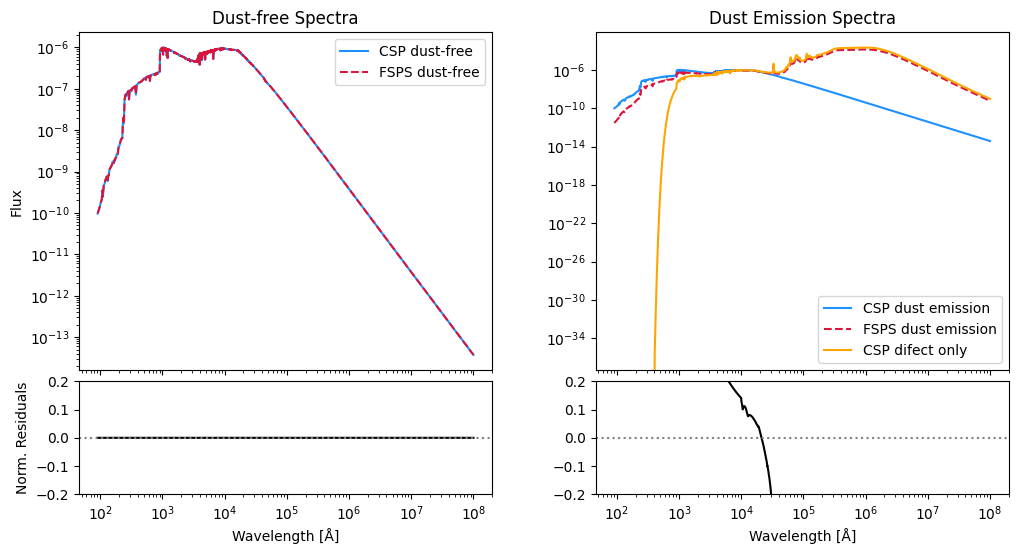

In [122]:
import matplotlib.pyplot as plt
import numpy as np

# --- Compute normalized residuals ---
resid_dustfree = (spectrum_csp_diff_dustfree - spec_fsps_dustfree) / spec_fsps_dustfree
resid_dustemi  = (spectrum_csp_diff - spec_fsps_dust_emi) / spec_fsps_dust_emi

# --- Set up figure with 2x2 subplots ---
fig, axes = plt.subplots(
    2, 2, figsize=(12, 6),
    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05, 'wspace': 0.25},
    sharex='col'
)

# Unpack axes
(ax_spec_dustfree, ax_spec_dustemi), (ax_resid_dustfree, ax_resid_dustemi) = axes

# --- Left column: Dust-free comparison ---
ax_spec_dustfree.loglog(csp_diff.wave, spectrum_csp_diff_dustfree, color='dodgerblue', label='CSP dust-free')
ax_spec_dustfree.loglog(wave, spec_fsps_dustfree, color='crimson', linestyle='--', label='FSPS dust-free')
ax_spec_dustfree.set_ylabel("Flux")
ax_spec_dustfree.legend()
ax_spec_dustfree.set_title("Dust-free Spectra")

# Residuals below
ax_resid_dustfree.plot(wave, resid_dustfree, color='black')
ax_resid_dustfree.axhline(0, color='gray', linestyle=':')
ax_resid_dustfree.set_xscale("log")
ax_resid_dustfree.set_xlabel("Wavelength [Å]")
ax_resid_dustfree.set_ylabel("Norm. Residuals")
ax_resid_dustfree.set_ylim(-0.2, 0.2)

# --- Right column: Dust-emission comparison ---
ax_spec_dustemi.loglog(csp_diff.wave, spectrum_csp_diff, color='dodgerblue', label='CSP dust emission')
ax_spec_dustemi.loglog(wave, spec_fsps_dust_emi, color='crimson', linestyle='--', label='FSPS dust emission')

ax_spec_dustemi.loglog(csp_diff.wave, specdust_hot, color='orange', label='CSP difect only')
ax_spec_dustemi.legend()
ax_spec_dustemi.set_title("Dust Emission Spectra")

# Residuals below
ax_resid_dustemi.plot(wave, resid_dustemi, color='black')
ax_resid_dustemi.axhline(0, color='gray', linestyle=':')
ax_resid_dustemi.set_xscale("log")
ax_resid_dustemi.set_xlabel("Wavelength [Å]")
ax_resid_dustemi.set_ylim(-0.2, 0.2)

plt.tight_layout()
plt.show()